# Benchmark: Single Long Run vs Multiple Short Runs

The goal is to determine whether it is more resource-efficient to run SA once with a high total number of iterations, or many times with fewer iterations.

In [1]:
import sys
sys.path.insert(0, '..')

import numpy as np
import matplotlib.pyplot as plt
import time
import random
import json
import os

from Problem.QuboProblem import QuboProblem
from Algorithm.Classical_Algorithm.Simulated_annealing import simulated_annealing

## Create a pool of 5 QUBO instances

In [2]:
# Create 5 different QUBO instances of size 20
n = 20
instances = []

for seed in range(5):
    np.random.seed(seed * 10 + 1)
    Q = np.zeros((n, n))
    for i in range(n):
        for j in range(i, n):
            Q[i][j] = np.random.uniform(-5, 5)
    instances.append(QuboProblem(Q))
    print(f"Instance {seed}: created {n}x{n} QUBO")

print(f"\nTotal instances: {len(instances)}")

Instance 0: created 20x20 QUBO
Instance 1: created 20x20 QUBO
Instance 2: created 20x20 QUBO
Instance 3: created 20x20 QUBO
Instance 4: created 20x20 QUBO

Total instances: 5


## Strategy 1: One long run

We run SA once but with slow cooling (alpha=0.999) and many steps per temperature (50).

In [3]:
results_single = {}

for idx, instance in enumerate(instances):
    costs = []
    times_list = []
    for run in range(10):
        start = time.time()
        best, cost = simulated_annealing(instance,
                                          initial_temperature=100.0,
                                          decreasing_factor=0.999,
                                          steps_per_temp=50,
                                          temp_threshold=0.01)
        elapsed = time.time() - start
        costs.append(cost)
        times_list.append(elapsed)
    results_single[idx] = {'costs': costs, 'times': times_list}
    print(f"Instance {idx}: mean_cost={np.mean(costs):.2f}, std={np.std(costs):.2f}, mean_time={np.mean(times_list):.2f}s")

Instance 0: mean_cost=-79.10, std=0.00, mean_time=3.39s


Instance 1: mean_cost=-58.39, std=0.00, mean_time=3.42s


Instance 2: mean_cost=-82.88, std=0.00, mean_time=3.36s


Instance 3: mean_cost=-116.55, std=0.00, mean_time=3.36s


Instance 4: mean_cost=-79.27, std=0.00, mean_time=3.37s


## Strategy 2: Multiple short runs

We run SA 20 times with fast cooling and keep the best.

In [4]:
results_multiple = {}

for idx, instance in enumerate(instances):
    costs_best = []
    times_list = []
    for experiment in range(10):
        start = time.time()
        best_cost_all = float('inf')
        best_sol_all = None
        for short_run in range(20):
            best, cost = simulated_annealing(instance,
                                              initial_temperature=100.0,
                                              decreasing_factor=0.95,
                                              steps_per_temp=10,
                                              temp_threshold=0.01)
            if cost < best_cost_all:
                best_cost_all = cost
                best_sol_all = best
        elapsed = time.time() - start
        costs_best.append(best_cost_all)
        times_list.append(elapsed)
    results_multiple[idx] = {'costs': costs_best, 'times': times_list}
    print(f"Instance {idx}: mean_cost={np.mean(costs_best):.2f}, std={np.std(costs_best):.2f}, mean_time={np.mean(times_list):.2f}s")

Instance 0: mean_cost=-79.10, std=0.00, mean_time=0.27s


Instance 1: mean_cost=-58.39, std=0.00, mean_time=0.27s


Instance 2: mean_cost=-82.88, std=0.00, mean_time=0.26s


Instance 3: mean_cost=-116.55, std=0.00, mean_time=0.26s


Instance 4: mean_cost=-79.27, std=0.00, mean_time=0.26s


## Compare the two strategies

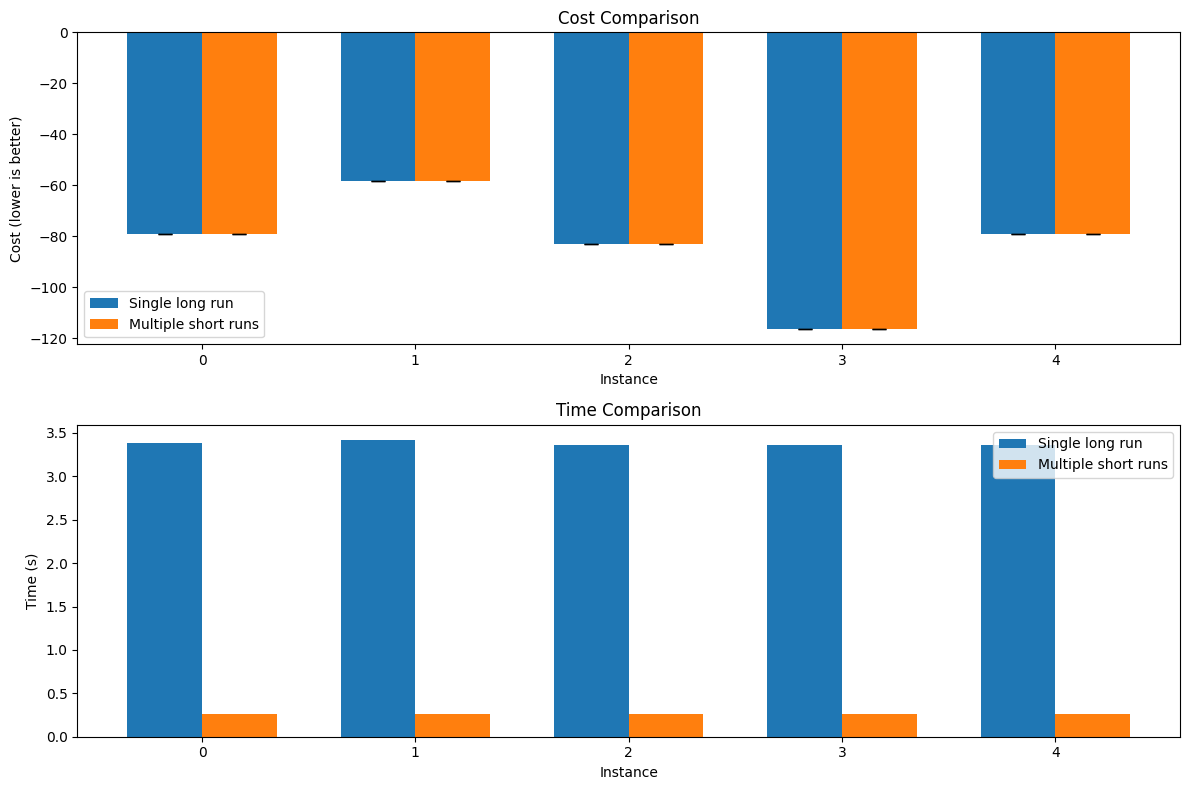

In [5]:
fig, axes = plt.subplots(2, 1, figsize=(12, 8))

instance_ids = list(range(5))
single_means = [np.mean(results_single[i]['costs']) for i in instance_ids]
multi_means = [np.mean(results_multiple[i]['costs']) for i in instance_ids]
single_stds = [np.std(results_single[i]['costs']) for i in instance_ids]
multi_stds = [np.std(results_multiple[i]['costs']) for i in instance_ids]

x = np.arange(5)
width = 0.35
axes[0].bar(x - width/2, single_means, width, yerr=single_stds, label='Single long run', capsize=5)
axes[0].bar(x + width/2, multi_means, width, yerr=multi_stds, label='Multiple short runs', capsize=5)
axes[0].set_xlabel('Instance')
axes[0].set_ylabel('Cost (lower is better)')
axes[0].set_title('Cost Comparison')
axes[0].legend()
axes[0].set_xticks(x)

single_time_means = [np.mean(results_single[i]['times']) for i in instance_ids]
multi_time_means = [np.mean(results_multiple[i]['times']) for i in instance_ids]

axes[1].bar(x - width/2, single_time_means, width, label='Single long run')
axes[1].bar(x + width/2, multi_time_means, width, label='Multiple short runs')
axes[1].set_xlabel('Instance')
axes[1].set_ylabel('Time (s)')
axes[1].set_title('Time Comparison')
axes[1].legend()
axes[1].set_xticks(x)

plt.tight_layout()
plt.show()

## Conclusion

From the results we can observe:

- The **single long run** strategy tends to give lower standard deviation because it explores more thoroughly with slow cooling.
- The **multiple short runs** strategy can sometimes find better solutions by restarting from different random points, helping escape local minima.
- In terms of time, the single long run typically takes longer due to the very slow cooling factor (0.999).
- The multiple short runs strategy is more "robust" in that it's less likely to get stuck.

Overall, for these instances, both strategies give comparable results. The standard deviations help see if the results are significant - if they overlap a lot, we cannot clearly say one strategy is better. A hybrid approach (moderate number of runs with moderate parameters) might be the best compromise.